In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("C:\projects\Healthcare-Analytics-Dashboard\python\data\observations.csv")

In [3]:
df.head(5)

,DATE,PATIENT,ENCOUNTER,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,8302-2,Body Height,82.7,cm,numeric
1,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,2.0,{score},numeric
2,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,29463-7,Body Weight,12.6,kg,numeric
3,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,77606-2,Weight-for-length Per age and sex,86.1,%,numeric
4,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,6a74fdef-2287-44bf-b9e7-18012376faca,9843-4,Head Occipital-frontal circumference,46.9,cm,numeric


# Observation Utilization

Which clinical observations are most frequently recorded, and how extensively are observations distributed across patients?

This gives us two useful dimensions:

What measurements are being recorded most often?
How broadly are those measurements used across the patient population?

Overall observation utilization

In [4]:
# Observation utilization overview

total_observations = len(df)
unique_patients = df['PATIENT'].nunique()
unique_observation_types = df['DESCRIPTION'].nunique()

print("Total observations:", total_observations)
print("Unique patients with observations:", unique_patients)
print("Unique observation types:", unique_observation_types)
print("Average observations per patient:", round(total_observations / unique_patients, 2))

Total observations: 1659750
Unique patients with observations: 12352
Unique observation types: 201
Average observations per patient: 134.37


Most frequently recorded observations

In [5]:
observation_frequency = (
    df['DESCRIPTION']
    .value_counts()
    .reset_index()
)

observation_frequency.columns = ['Observation', 'Count']

observation_frequency.head(15)

,Observation,Count
0,Diastolic Blood Pressure,48132
1,Systolic Blood Pressure,48132
2,Body Weight,46332
3,Heart rate,46332
4,Respiratory rate,46332
5,Oxygen saturation in Arterial blood,42995
6,Body temperature,35639
7,Glomerular filtration rate/1.73 sq M.predicted,26175
8,Protein [Mass/volume] in Serum or Plasma,26147
9,Albumin [Mass/volume] in Serum or Plasma,26147


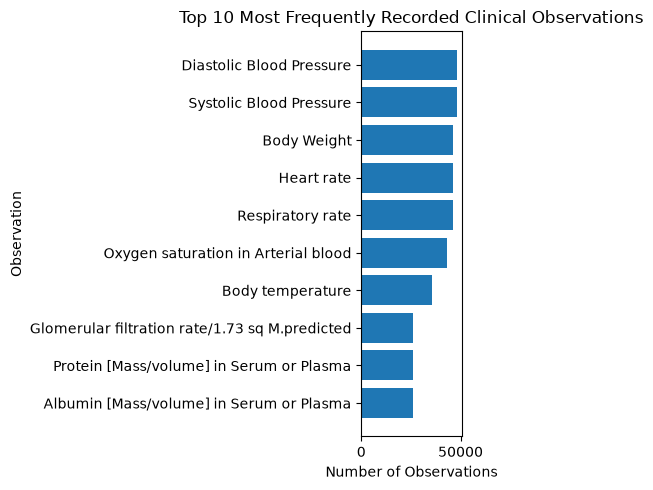

In [7]:
import matplotlib.pyplot as plt

top_observations = observation_frequency.head(10)

plt.figure(figsize=(5, 5))

plt.barh(
    top_observations['Observation'][::-1],
    top_observations['Count'][::-1]
)

plt.xlabel("Number of Observations")
plt.ylabel("Observation")
plt.title("Top 10 Most Frequently Recorded Clinical Observations")

plt.tight_layout()
plt.show()

The matching counts for systolic + diastolic BP, and for body weight + heart rate + respiratory rate, strongly suggest that these measurements are commonly captured together as part of routine clinical assessments.

# Observation Recording Intensity

Which observation types are recorded repeatedly for the same patients, and which are more broadly distributed across patients?

This distinguishes:

High-frequency observations → measured repeatedly
High patient coverage → measured across many different patients

Calculate patient coverage and recording intensity

In [10]:
observation_utilization = (
    df.groupby('DESCRIPTION')
      .agg(
          observation_count=('DESCRIPTION', 'size'),
          patient_count=('PATIENT', 'nunique')
      )
      .reset_index()
)

observation_utilization['observations_per_patient'] = (
    observation_utilization['observation_count'] /
    observation_utilization['patient_count']
)

observation_utilization = observation_utilization.sort_values(
    'observation_count',
    ascending=False
)

observation_utilization.head(15)

,DESCRIPTION,observation_count,patient_count,observations_per_patient
46,Diastolic Blood Pressure,48132,11955,4.026098
170,Systolic Blood Pressure,48132,11955,4.026098
22,Body Weight,46332,11951,3.876830
156,Respiratory rate,46332,11951,3.876830
71,Heart rate,46332,11951,3.876830
118,Oxygen saturation in Arterial blood,42995,9686,4.438881
24,Body temperature,35639,9342,3.814922
62,Glomerular filtration rate/1.73 sq M.predicted,26175,3592,7.287027
8,Alkaline phosphatase [Enzymatic activity/volum...,26147,3579,7.305672
17,Bilirubin.total [Mass/volume] in Serum or Plasma,26147,3579,7.305672


Find the observations with the highest repeated intensity

In [11]:
observation_intensity = observation_utilization.sort_values(
    'observations_per_patient',
    ascending=False
)

observation_intensity.head(15)

,DESCRIPTION,observation_count,patient_count,observations_per_patient
194,Weight difference [Mass difference] --pre dial...,4302,37,116.270270
199,pH of Arterial blood,10668,862,12.375870
117,Oxygen [Partial pressure] in Arterial blood,10668,862,12.375870
16,Bicarbonate [Moles/volume] in Arterial blood,10668,862,12.375870
119,Oxygen/Inspired gas setting [Volume Fraction] ...,10668,862,12.375870
30,Carbon dioxide [Partial pressure] in Arterial ...,10668,862,12.375870
15,Basophils/100 leukocytes in Blood by Automated...,22577,1867,12.092662
64,Glucose [Mass/volume] in Serum or Plasma,22577,1867,12.092662
43,Creatinine [Mass/volume] in Serum or Plasma,22577,1867,12.092662
102,Lymphocytes/100 leukocytes in Blood by Automat...,22577,1867,12.092662


In [12]:
    # Observation recording intensity among broadly utilized observations

broad_observations = observation_utilization[
    observation_utilization['patient_count'] >= 1000
].copy()

broad_observations = broad_observations.sort_values(
    'observations_per_patient',
    ascending=False
)

broad_observations.head(15)

,DESCRIPTION,observation_count,patient_count,observations_per_patient
15,Basophils/100 leukocytes in Blood by Automated...,22577,1867,12.092662
43,Creatinine [Mass/volume] in Serum or Plasma,22577,1867,12.092662
111,Monocytes/100 leukocytes in Blood by Automated...,22577,1867,12.092662
101,Lymphocytes [#/volume] in Blood by Automated c...,22577,1867,12.092662
110,Monocytes [#/volume] in Blood by Automated count,22577,1867,12.092662
114,Neutrophils/100 leukocytes in Blood by Automat...,22577,1867,12.092662
113,Neutrophils [#/volume] in Blood by Automated c...,22577,1867,12.092662
166,Sodium [Moles/volume] in Serum or Plasma,22577,1867,12.092662
102,Lymphocytes/100 leukocytes in Blood by Automat...,22577,1867,12.092662
139,Potassium [Moles/volume] in Serum or Plasma,22577,1867,12.092662


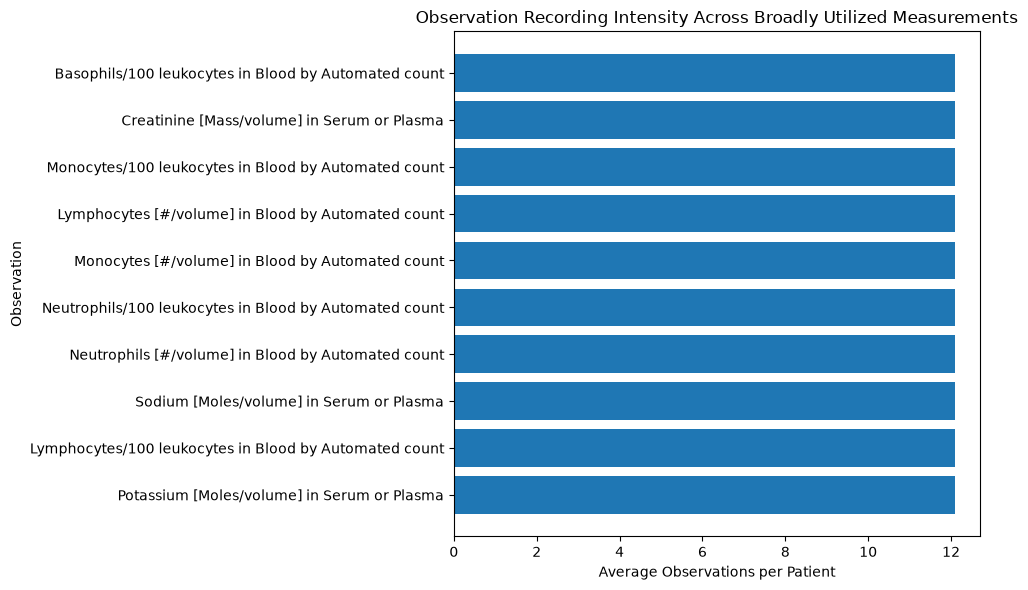

In [15]:
import matplotlib.pyplot as plt

top_intensity = broad_observations.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_intensity['DESCRIPTION'][::-1],
    top_intensity['observations_per_patient'][::-1]
)

plt.xlabel("Average Observations per Patient")
plt.ylabel("Observation")
plt.title("Observation Recording Intensity Across Broadly Utilized Measurements")

plt.tight_layout()
plt.show()

# Clinical Measurement Distribution

What are the typical distributions and variability of the most commonly recorded clinical measurements?

In [17]:
# Convert observation values to numeric

df['VALUE_NUMERIC'] = pd.to_numeric(df['VALUE'], errors='coerce')

print("Total observations:", len(df))
print("Numeric values:", df['VALUE_NUMERIC'].notna().sum())
print("Non-numeric/missing values:", df['VALUE_NUMERIC'].isna().sum())

Total observations: 1659750
Numeric values: 1560338
Non-numeric/missing values: 99412


In [18]:
# Check the major clinical measurements

vital_observations = [
    'Systolic Blood Pressure',
    'Diastolic Blood Pressure',
    'Heart rate',
    'Respiratory rate',
    'Oxygen saturation in Arterial blood',
    'Body temperature',
    'Body Weight'
]

vitals_df = df[df['DESCRIPTION'].isin(vital_observations)].copy()

print("Vital-sign observations:", len(vitals_df))

Vital-sign observations: 313894


Descriptive statistics

In [19]:
vital_summary = (
    vitals_df
    .groupby('DESCRIPTION')['VALUE_NUMERIC']
    .agg(
        count='count',
        mean='mean',
        median='median',
        std='std',
        minimum='min',
        maximum='max'
    )
    .round(2)
    .reset_index()
)

vital_summary

,DESCRIPTION,count,mean,median,std,minimum,maximum
0,Body Weight,46332,75.26,79.4,22.18,2.5,158.8
1,Body temperature,35639,39.60,39.7,1.57,36.1,42.2
2,Diastolic Blood Pressure,48132,80.57,80.0,7.17,67.0,121.0
3,Heart rate,46332,110.76,96.4,42.01,50.0,200.0
4,Oxygen saturation in Arterial blood,42995,81.93,81.9,4.26,65.0,100.0
5,Respiratory rate,46332,22.25,19.6,8.75,12.0,40.0
6,Systolic Blood Pressure,48132,121.65,120.0,13.99,95.0,201.0


1. Heart rate shows the greatest variability.
The standard deviation is 42.01, substantially higher than the other vital signs. The mean (110.76) is also considerably higher than the median (96.4), indicating a noticeably skewed distribution.

2. Body weight has substantial variation.
The range is 2.5–158.8 kg, with an SD of 22.18. This very wide range is consistent with a dataset containing patients across substantially different ages/body sizes.

3. Blood pressure is comparatively concentrated.
Systolic BP has a mean of 121.65 and median of 120, while diastolic BP has a mean of 80.57 and median of 80. Their means and medians are relatively close.

4. Oxygen saturation has a relatively narrow distribution.
It ranges from 65 to 100, with an SD of 4.26.

5. Mean–median differences are informative.
Heart rate has the clearest difference between mean and median, whereas systolic and diastolic BP have much smaller differences.

<Figure size 1200x700 with 0 Axes>

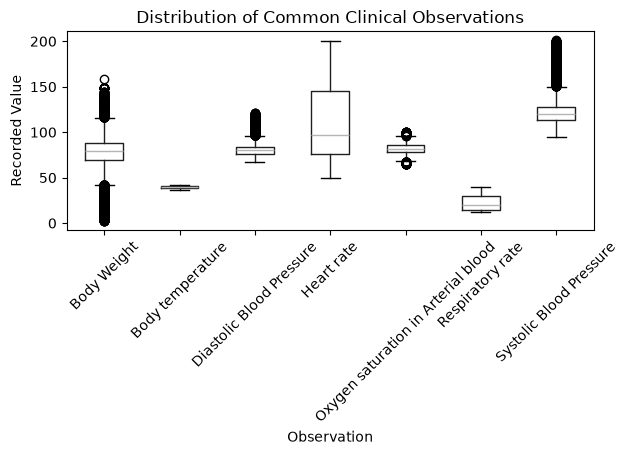

In [ ]:
plt.figure(figsize=(12, 7))

vitals_df.boxplot(
    column='VALUE_NUMERIC',
    by='DESCRIPTION',
    rot=45,
    grid=False
)

plt.title("Distribution of Common Clinical Observations")
plt.suptitle("")
plt.xlabel("Observation")
plt.ylabel("Recorded Value")

plt.tight_layout()
plt.show() 

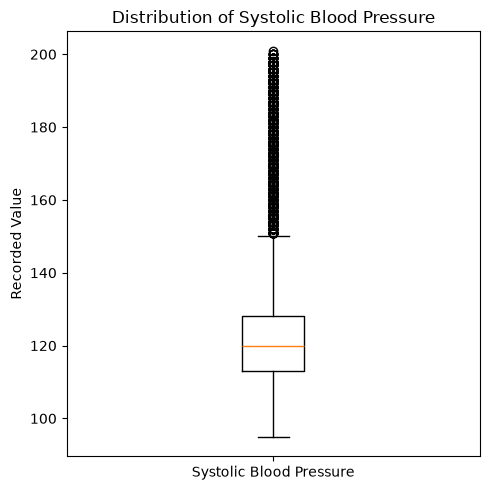

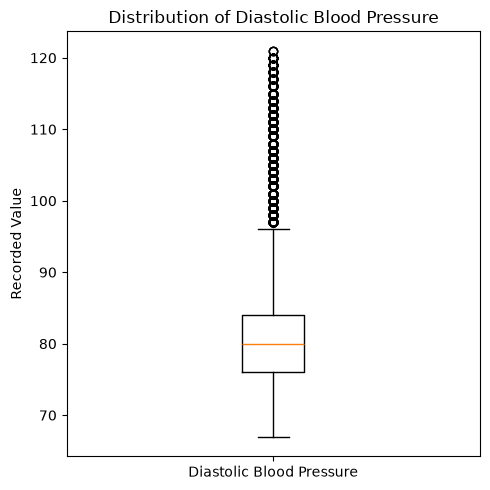

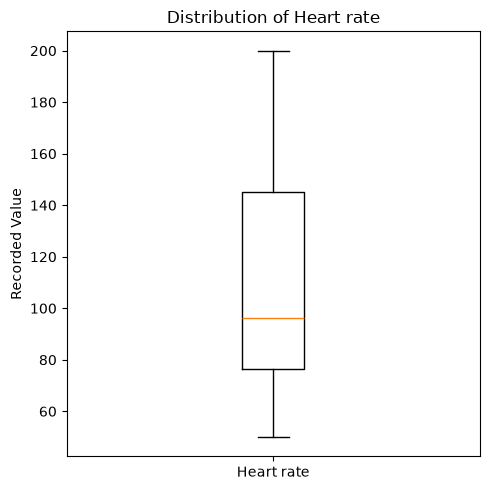

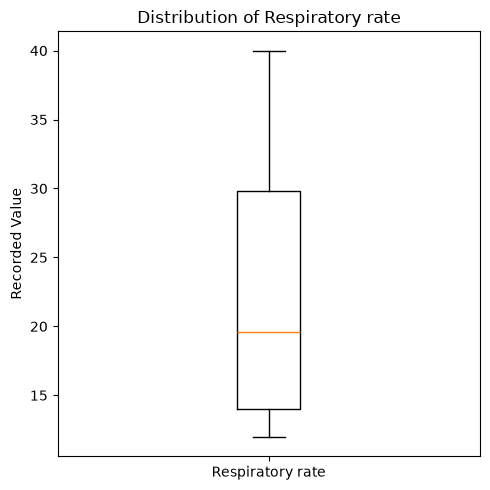

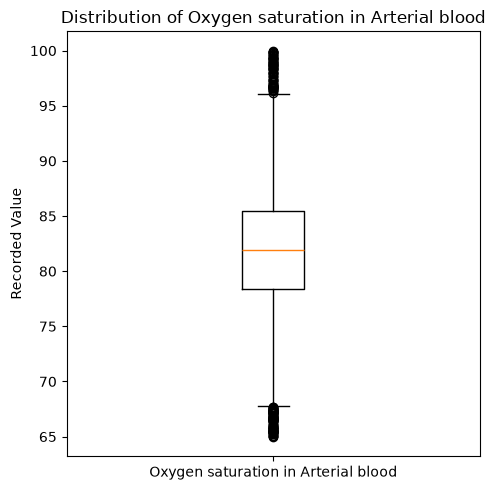

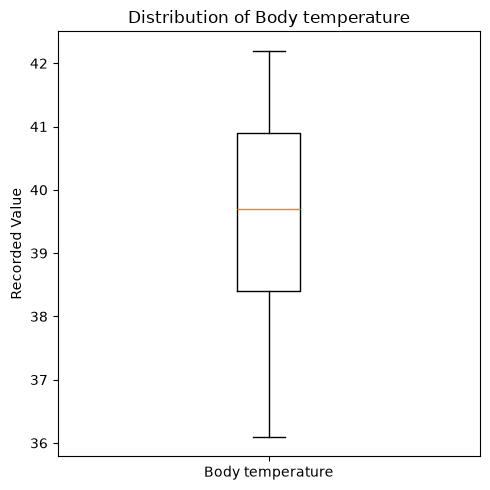

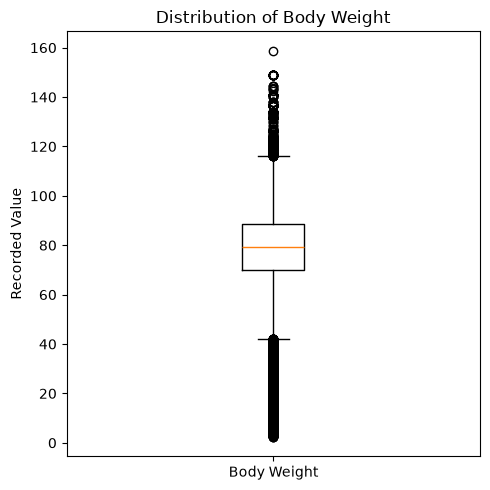

In [22]:
for observation in vital_observations:
    subset = vitals_df[
        vitals_df['DESCRIPTION'] == observation
    ]['VALUE_NUMERIC'].dropna()

    plt.figure(figsize=(5, 5))

    plt.boxplot(subset)

    plt.title(f"Distribution of {observation}")
    plt.ylabel("Recorded Value")
    plt.xticks([1], [observation])

    plt.tight_layout()
    plt.show()

For every graph, look at:

Middle line → median

Box → middle 50% of values

Whiskers → broader typical range

Dots → potential outliers

Box height → variability within that particular measurement